# The Duck That's Complicating California's Grid

*This notebook is the full analysis behind the YouTube video "The Duck That's Complicating California's Grid." The video tells the story for a general audience; this notebook shows the data and methodology behind it.*

**Author:** Sam Macuga  
**Course:** Storytelling with Data (PSYC 81.09), Dartmouth College  
**Video:** https://youtu.be/Zbpk6JHVpqI

# Background and overview

**Research question:** How has the rapid growth of solar generation reshaped the hourly shape of electricity demand on California's grid, and what operational challenges has that shift created?

## Approach

Using 5-minute resolution operating data from CAISO's Today's Outlook dashboard, I compared a representative spring week across nine consecutive years from 2018 to 2026. Net load (demand minus all renewable generation) was computed for each hour to show how the shape operators actually have to manage has changed. Battery dispatch data, also from CAISO, shows how grid-scale storage is now reshaping that curve.

## Quick summary of findings

- The midday net load belly has deepened from about +9 GW in 2018 to about −6 GW in 2026, a 15 GW drop in 9 years driven by solar growth.
- The evening peak has held essentially flat at 20–22 GW across the same period, so the evening ramp has roughly doubled: from ~13 GW in 2018 to ~26 GW in 2026.
- Grid-scale batteries have gone from a rounding error in 2018 to discharging close to 9 GW during the evening cliff on an average spring weekday in 2026, taking on a meaningful share of the ramp that would otherwise fall on gas plants.

# Data

All data for this analysis comes from CAISO's Today's Outlook dashboard (https://www.caiso.com/todays-outlook), which publishes 5-minute resolution operating data for the California grid. For each weekday in the spring week of April 14-18, in every year from 2018 through 2026, I downloaded two CSVs:

- The **Net Demand** export, which contains hourly demand
- The **Supply** export, which contains hourly output by fuel type, including a Batteries row that captures grid-scale battery dispatch

This gives me 9 years × 5 weekdays = 45 days of consistent 5-minute data from a single source. For each day I aggregate to hourly (averaging the twelve 5-minute intervals per hour) and then average across the 5 weekdays to get a representative spring weekday profile for each year. Spring was chosen because it isolates the duck curve most cleanly: demand is moderate without heavy summer cooling or winter heating loads, while solar generation is already strong, so the dip from solar is most visible without being masked by seasonal demand swings.

**A note on what CAISO's "demand" actually measures.** CAISO's demand series is net of behind-the-meter rooftop solar — it reports what gets pulled from the grid, not what California's homes and businesses are actually consuming. So even the "demand" curves in this analysis already have some solar subtraction baked in, which is why a small midday dip is visible even in the 2018 demand curve. The duck shape this analysis is about emerges when you additionally subtract utility-scale renewables (large solar farms, wind, geothermal) from that already-net-of-rooftop figure. The contrast that drives the story is the *magnitude* of that second subtraction, not the existence of any midday dip at all.

**Net load is computed as demand minus renewables**, where Renewables in CAISO's reporting includes utility-scale solar, wind, geothermal, biomass, and small hydro. This matches how CAISO's own dashboard labels the "Net demand" series. The result differs slightly from the traditional `demand − solar − wind` definition (because it also subtracts ~3 GW of baseload renewables like geothermal), but it's consistent across all 9 years and matches the operating metric CAISO actually uses.

For Figure 4 (batteries), I use the Batteries row directly from the supply CSV. In 2018-2019 this row is essentially zero (CAISO had less than 200 MW of grid-scale storage). By 2026 it shows discharge peaks of nearly 9 GW in the evening and equivalent charging during midday. The growth of this row over the 9 years is itself one of the story's key facts.

All timestamps are in Pacific time, which is what CAISO publishes natively, so no timezone conversion is needed.

## Files needed to run this notebook

All CSVs are bundled in `CAISO_data.zip`. Upload it to `/content/` in Colab (drag it into the file panel on the left), then run the unzip cell below. The next cell will load all the data from the extracted files.


In [27]:
# Unzip the CAISO data files (only needed once per Colab session)
# Upload CAISO_data.zip to /content/ via the file panel, then run this cell.

import zipfile
from pathlib import Path

zip_path = '/content/CAISO_data.zip'
extract_to = '/content'

if not Path(zip_path).exists():
    raise FileNotFoundError(
        f"{zip_path} not found. Upload CAISO_data.zip to /content/ first "
        f"(drag it into the Colab file panel on the left)."
    )

with zipfile.ZipFile(zip_path) as z:
    z.extractall(extract_to)

# Count what we extracted
supply_files = list(Path(extract_to).glob('CAISO-supply-*.csv'))
netdemand_files = list(Path(extract_to).glob('CAISO-netdemand-*.csv'))
print(f"Extracted {len(supply_files)} supply files and {len(netdemand_files)} netdemand files")


Extracted 45 supply files and 45 netdemand files


In [28]:
# Load CAISO Today's Outlook CSVs
# Files are named CAISO-supply-YYYYMMDD.csv and CAISO-netdemand-YYYYMMDD.csv
# and should live in /content/ (Colab default upload location)

import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = '/content'  # change if running locally

def load_caiso_day(year, month, day, data_dir=DATA_DIR):
    """Load one day of CAISO data and return hourly demand, renewables, batteries in GW.

    Returns a dict with keys 'demand', 'renewables', 'batteries', each a 24-element
    numpy array (one value per hour, Pacific time). Returns None if files are missing.
    """
    date_str = f'{year}{month:02d}{day:02d}'
    sup_f = Path(data_dir) / f'CAISO-supply-{date_str}.csv'
    nd_f = Path(data_dir) / f'CAISO-netdemand-{date_str}.csv'
    if not sup_f.exists() or not nd_f.exists():
        return None

    # CAISO CSVs sometimes have inconsistent column counts across rows,
    # so we use the python engine with on_bad_lines='skip' to be tolerant.
    sup = pd.read_csv(sup_f, header=None, engine='python', on_bad_lines='skip')
    nd = pd.read_csv(nd_f, header=None, engine='python', on_bad_lines='skip')

    def get_row(df, exact_label):
        # Match exact (whitespace-stripped) label in the first column.
        # 'Demand' must not match 'Net Demand 04/14/2026' header row.
        for i, val in enumerate(df.iloc[:, 0].astype(str)):
            if val.strip() == exact_label:
                return pd.to_numeric(df.iloc[i, 1:289], errors='coerce').values
        return None

    demand = get_row(nd, 'Demand')
    renewables = get_row(sup, 'Renewables')
    batteries = get_row(sup, 'Batteries')
    if demand is None or renewables is None:
        return None
    if batteries is None or pd.isna(batteries).all():
        # Early years (2018-2019) may have all-zero or missing battery rows
        batteries = np.zeros(288)

    # Aggregate 288 five-minute values to 24 hourly averages
    def to_hourly_gw(arr):
        return np.nanmean(np.array(arr[:288]).astype(float).reshape(24, 12), axis=1) / 1000

    return {
        'demand': to_hourly_gw(demand),
        'renewables': to_hourly_gw(renewables),
        'batteries': to_hourly_gw(batteries),
    }

def load_year_average(year, days=range(14, 19), month=4):
    """Average across the 5 weekdays (Mon-Fri) of April 14-18 for the given year."""
    daily = [load_caiso_day(year, month, d) for d in days]
    daily = [d for d in daily if d is not None]
    if not daily:
        return None
    return {
        'net_load': np.nanmean([d['demand'] - d['renewables'] for d in daily], axis=0),
        'batteries': np.nanmean([d['batteries'] for d in daily], axis=0),
        'demand': np.nanmean([d['demand'] for d in daily], axis=0),
    }

# Load every year from 2018 through 2026
years_data = {y: load_year_average(y) for y in range(2018, 2027)}
years_data = {y: d for y, d in years_data.items() if d is not None}
print(f"Loaded {len(years_data)} years of CAISO data: {list(years_data.keys())}")

# Quick summary of what we loaded
for y, d in years_data.items():
    belly = d['net_load'].min()
    peak = d['net_load'].max()
    print(f"  {y}: belly {belly:+5.1f} GW, peak {peak:+5.1f} GW, battery range [{d['batteries'].min():+5.1f}, {d['batteries'].max():+5.1f}] GW")

FIRST_YEAR = min(years_data.keys())
LATEST_YEAR = max(years_data.keys())


Loaded 9 years of CAISO data: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
  2018: belly  +9.3 GW, peak +22.5 GW, battery range [ -0.0,  +0.0] GW
  2019: belly  +8.6 GW, peak +22.8 GW, battery range [ -0.0,  +0.0] GW
  2020: belly  +5.5 GW, peak +19.7 GW, battery range [ -0.0,  +0.0] GW
  2021: belly  +3.1 GW, peak +21.4 GW, battery range [ -0.1,  +0.1] GW
  2022: belly  +3.3 GW, peak +19.2 GW, battery range [ -0.6,  +1.4] GW
  2023: belly  -0.5 GW, peak +19.3 GW, battery range [ -2.0,  +2.7] GW
  2024: belly  -1.2 GW, peak +20.2 GW, battery range [ -4.0,  +4.7] GW
  2025: belly  -3.5 GW, peak +20.1 GW, battery range [ -4.9,  +6.2] GW
  2026: belly  -5.5 GW, peak +20.8 GW, battery range [ -8.6,  +8.7] GW


# Analysis

The figures below tell the duck curve story in five steps: what a normal day on the grid looked like before significant solar penetration, what net load looks like now, why the evening ramp matters operationally, how the shape has evolved year by year, and what grid-scale batteries are doing about it.

## Figure 0: A normal day on the grid

To understand the duck curve, it helps to first see the shape of demand by itself, separately from how it gets supplied. Figure 0 shows total grid demand on an average spring weekday, plotted hour by hour. The shape is roughly low overnight, climbs through the morning, dips through the middle of the day, and peaks in the evening as people come home and turn things on.

The midday dip is worth noting. As discussed in the Data section, CAISO's "demand" series is net of behind-the-meter rooftop solar, so even this baseline curve already has some solar subtraction in it. The figures that follow show what happens when utility-scale renewables get subtracted on top of that — which is where the duck curve actually emerges.

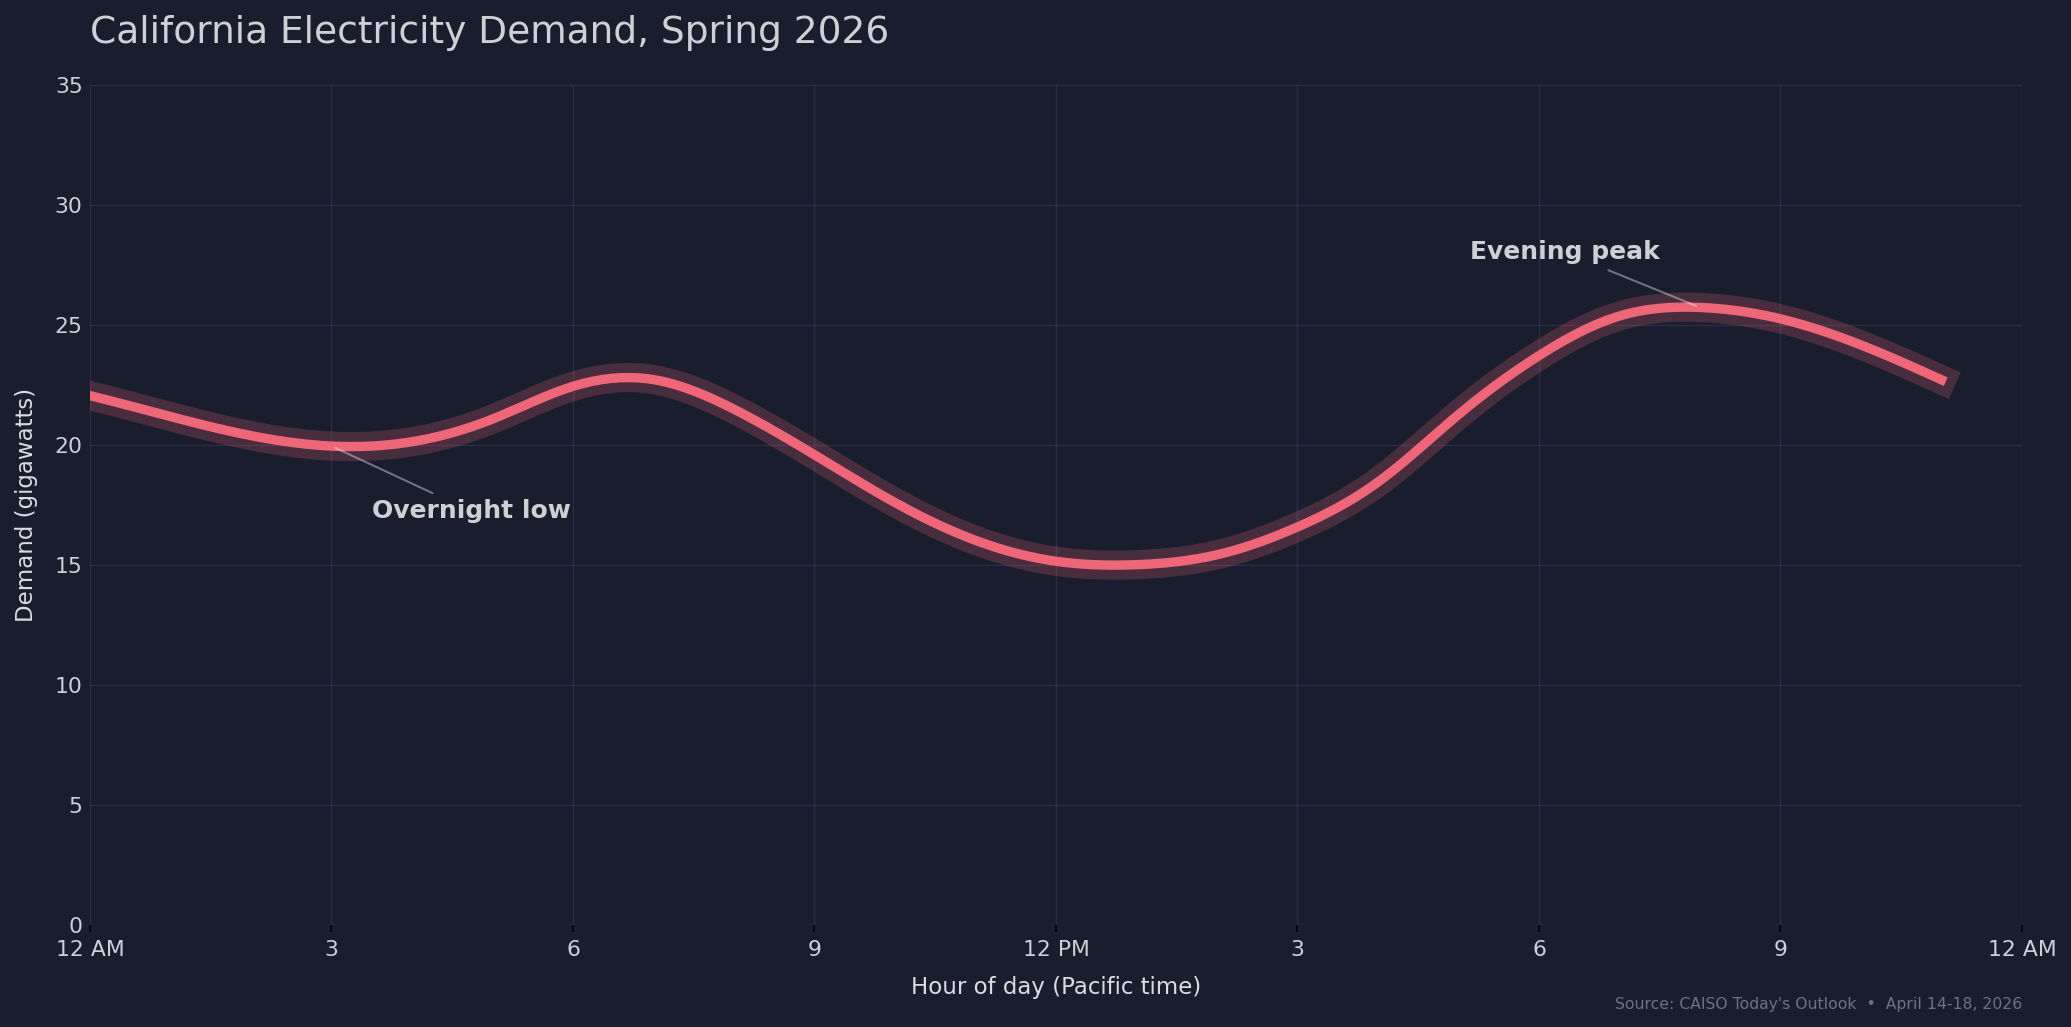

In [29]:
# Figure 0: A normal day on the grid
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

BG = '#1a1d2e'
TEXT = '#f0f0f5'
CORAL = '#EE6677'
GRID = '#3a3f5a'

demand_first = years_data[LATEST_YEAR]['demand']
hours = np.arange(24)
hours_smooth = np.linspace(0, 23, 200)
def smooth(arr):
    return interp1d(hours, arr, kind='cubic')(hours_smooth)

fig = plt.figure(figsize=(14, 7), dpi=150)
fig.patch.set_facecolor(BG)
ax = fig.add_axes([0.065, 0.10, 0.92, 0.80])
ax.set_facecolor(BG)
ax.grid(color=GRID, alpha=0.5, linewidth=0.7, zorder=0)

ax.plot(hours_smooth, smooth(demand_first), color=CORAL, linewidth=14, alpha=0.22, zorder=2)
ax.plot(hours_smooth, smooth(demand_first), color=CORAL, linewidth=4.5, alpha=1.0, zorder=3)

low_idx = int(np.argmin(demand_first[2:7])) + 2
peak_idx = int(np.argmax(demand_first[16:22])) + 16
ax.annotate('Overnight low', xy=(low_idx, demand_first[low_idx]),
    xytext=(low_idx + 0.5, demand_first[low_idx] - 3),
    color=TEXT, fontsize=12, fontweight='bold', alpha=0.85, ha='left',
    arrowprops=dict(arrowstyle='-', color=TEXT, alpha=0.4, lw=1))
ax.annotate('Evening peak', xy=(peak_idx, demand_first[peak_idx]),
    xytext=(peak_idx - 0.5, demand_first[peak_idx] + 2),
    color=TEXT, fontsize=12, fontweight='bold', alpha=0.85, ha='right',
    arrowprops=dict(arrowstyle='-', color=TEXT, alpha=0.4, lw=1))

ax.set_xlabel('Hour of day (Pacific time)', fontsize=11, color=TEXT, alpha=0.9, labelpad=8)
ax.set_ylabel('Demand (gigawatts)', fontsize=11, color=TEXT, alpha=0.9, labelpad=8)
ax.set_xlim(0, 24)
ax.set_ylim(0, 28)
ax.set_xticks(np.arange(0, 25, 3))
ax.set_xticklabels(['12 AM', '3', '6', '9', '12 PM', '3', '6', '9', '12 AM'],
                    fontsize=10.5, color=TEXT, alpha=0.85)
ax.set_yticks(np.arange(0, 36, 5))
ax.tick_params(axis='y', colors=TEXT, length=0, labelsize=10.5)
for label in ax.get_yticklabels():
    label.set_alpha(0.85)
for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(0.065, 0.94, f"California Electricity Demand, Spring {LATEST_YEAR}",
         fontsize=18, color=TEXT, alpha=0.85)
fig.text(0.985, 0.02, f"Source: CAISO Today's Outlook  \u2022  April 14-18, {LATEST_YEAR}",
         fontsize=7.5, color=TEXT, alpha=0.4, ha='right')

plt.savefig('/content/fig0_normal_day.png', facecolor=BG, dpi=150, bbox_inches='tight')
plt.show()

## Figure 1: Meet the duck

Now let's see what happens when we account for solar. Figure 1 plots two things: California's 2018 total demand (the smooth pre-solar curve from Figure 0, in pink) and 2026 net load (in blue). Net load is what's left after solar and other renewables have done their share — it's the residual demand that fossil plants, nuclear, hydro, imports, and batteries have to actually supply.

In 2018, demand and net load were nearly the same curve because there wasn't much utility-scale solar yet. By 2026, with California having built more solar capacity than any other state in the country, the midday net load plummets — well below zero, meaning renewables are producing more than the grid needs. Then sunset hits and net load shoots back up to meet the evening peak. The result is the shape that gave the duck curve its name: a flat back, a deep belly, and a sharp head at sunset.

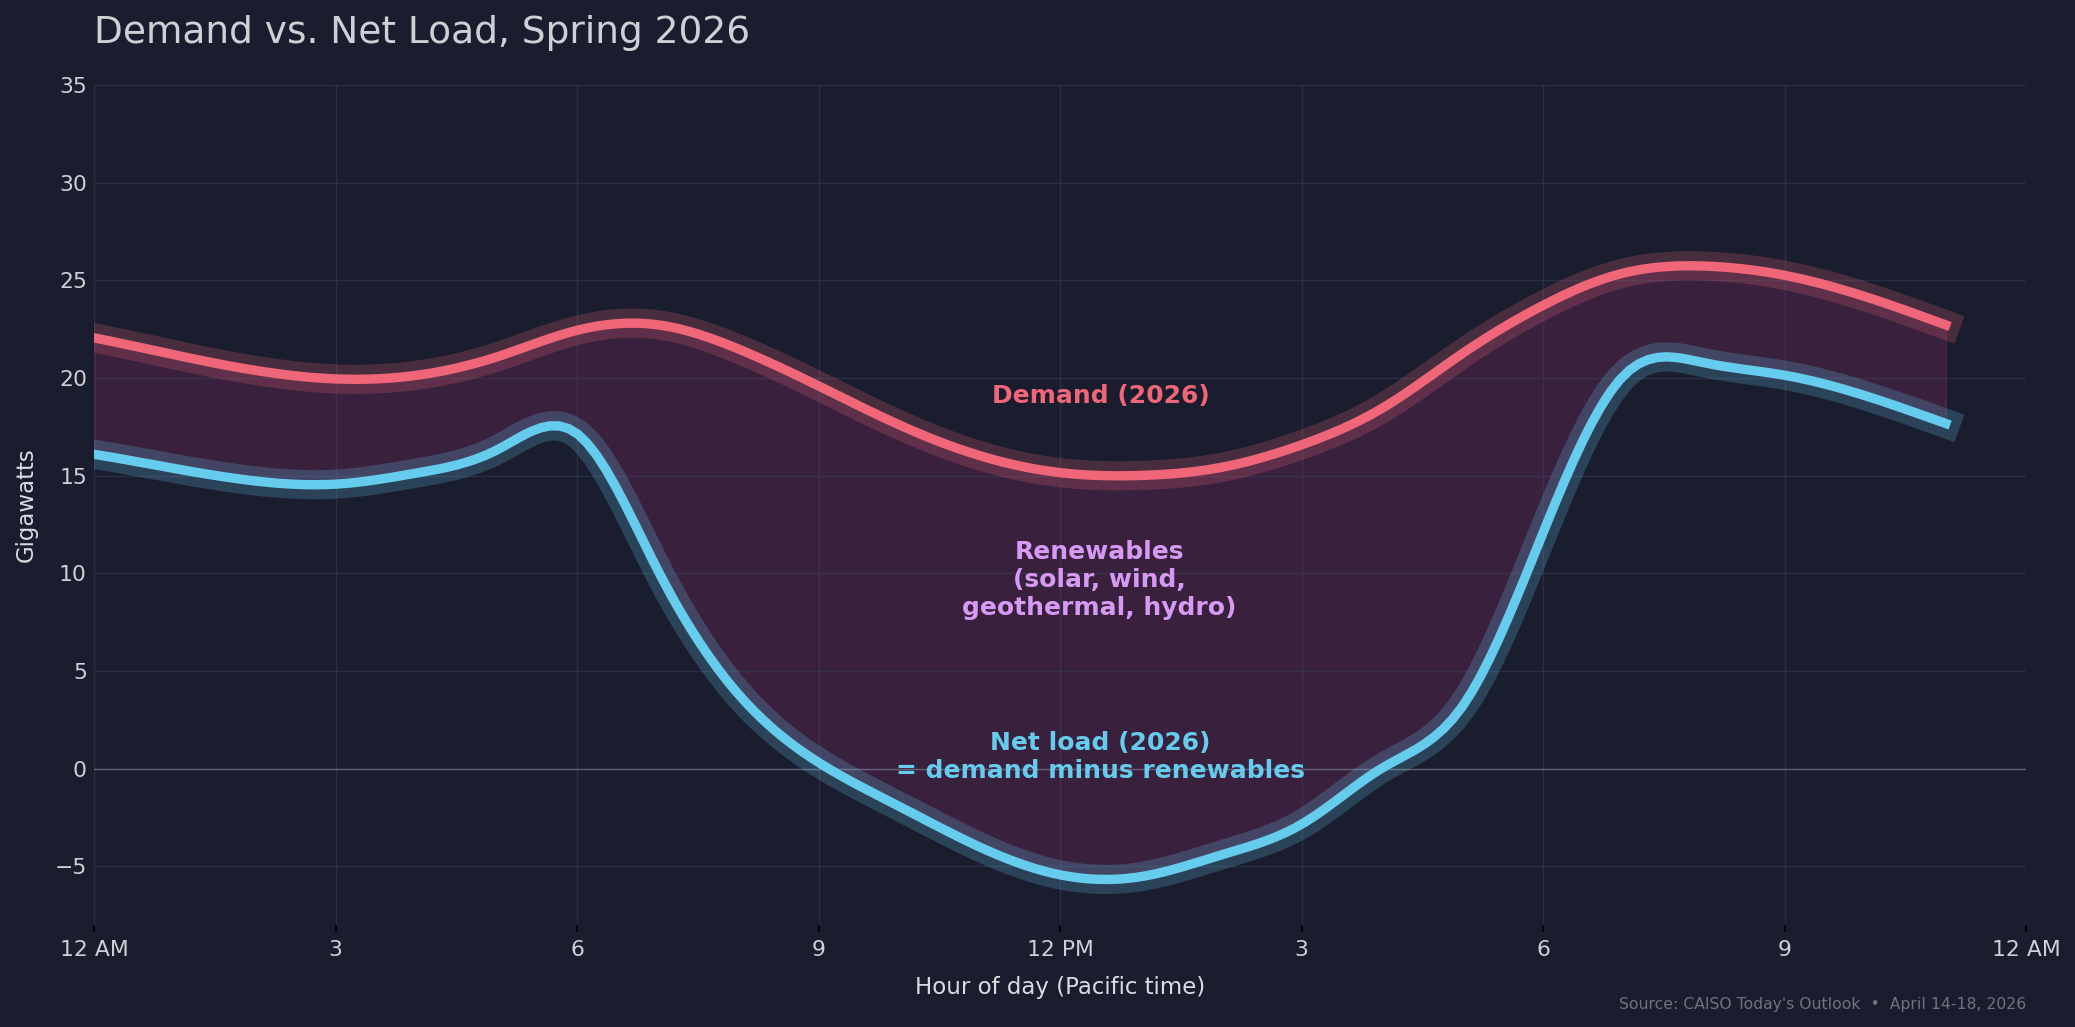

In [30]:
# Figure 1: Meet the duck
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

BG = '#1a1d2e'
TEXT = '#f0f0f5'
CORAL = '#EE6677'
CYAN = '#66CCEE'
PURPLE = '#AA3377'
GRID = '#3a3f5a'
LAVENDER = '#E0A0FF'

demand_first = years_data[LATEST_YEAR]['demand']
netload_latest = years_data[LATEST_YEAR]['net_load']
hours = np.arange(24)
hours_smooth = np.linspace(0, 23, 200)
def smooth(arr):
    return interp1d(hours, arr, kind='cubic')(hours_smooth)

d_smooth = smooth(demand_first)
nl_smooth = smooth(netload_latest)

fig = plt.figure(figsize=(14, 7), dpi=150)
fig.patch.set_facecolor(BG)
ax = fig.add_axes([0.065, 0.10, 0.92, 0.80])
ax.set_facecolor(BG)
ax.grid(color=GRID, alpha=0.5, linewidth=0.7, zorder=0)
ax.axhline(0, color=TEXT, alpha=0.25, linewidth=0.7)

ax.fill_between(hours_smooth, nl_smooth, d_smooth,
                color=PURPLE, alpha=0.22, zorder=1)

ax.plot(hours_smooth, d_smooth, color=CORAL, linewidth=14, alpha=0.22, zorder=2)
ax.plot(hours_smooth, d_smooth, color=CORAL, linewidth=4.5, alpha=1.0, zorder=3)
ax.plot(hours_smooth, nl_smooth, color=CYAN, linewidth=14, alpha=0.22, zorder=2)
ax.plot(hours_smooth, nl_smooth, color=CYAN, linewidth=4.5, alpha=1.0, zorder=3)

ax.text(12.5, demand_first[7] - 4, f'Demand ({LATEST_YEAR})',
        color=CORAL, fontsize=12, fontweight='bold', ha='center')
ax.text(12.5, netload_latest[16] - 0.5, f'Net load ({LATEST_YEAR})\n= demand minus renewables',
        color=CYAN, fontsize=12, fontweight='bold', ha='center')

gap = d_smooth - nl_smooth
widest_idx = int(np.argmax(gap))
mid_y = (d_smooth[widest_idx] + nl_smooth[widest_idx]) / 2
ax.text(hours_smooth[widest_idx], mid_y + 5, 'Renewables\n(solar, wind,\ngeothermal, hydro)',
        color=LAVENDER, fontsize=12, fontweight='bold', ha='center', va='center', alpha=0.95)

ax.set_xlabel('Hour of day (Pacific time)', fontsize=11, color=TEXT, alpha=0.9, labelpad=8)
ax.set_ylabel('Gigawatts', fontsize=11, color=TEXT, alpha=0.9, labelpad=8)
ax.set_xlim(0, 24)
ax.set_ylim(-8, 28)
ax.set_xticks(np.arange(0, 25, 3))
ax.set_xticklabels(['12 AM', '3', '6', '9', '12 PM', '3', '6', '9', '12 AM'],
                    fontsize=10.5, color=TEXT, alpha=0.85)
ax.set_yticks(np.arange(-5, 36, 5))
ax.tick_params(axis='y', colors=TEXT, length=0, labelsize=10.5)
for label in ax.get_yticklabels():
    label.set_alpha(0.85)
for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(0.065, 0.94, f"Demand vs. Net Load, Spring {LATEST_YEAR}",
         fontsize=18, color=TEXT, alpha=0.85)
fig.text(0.985, 0.02, f"Source: CAISO Today's Outlook  \u2022  April 14-18, {LATEST_YEAR}",
         fontsize=7.5, color=TEXT, alpha=0.4, ha='right')

plt.savefig('/content/fig1_duck.png', facecolor=BG, dpi=150, bbox_inches='tight')
plt.show()

## Figure 2: The cliff

The most operationally demanding part of the duck isn't the depth of the belly — it's the speed of the climb out of it. Figure 2 zooms in on the 2026 evening ramp: from the belly's deepest point in the early afternoon (well below zero) to the evening peak around 8 PM (around 21 GW), CAISO's non-renewable generation has to ramp up roughly 26 GW in 7 hours. That's the equivalent of starting up around fifty large natural gas plants every single afternoon, then shutting most of them back down overnight.

Grid operators call this "the cliff." A large gas plant takes hours to heat up from cold to full output, and even one that's already running can only ramp up so fast without damaging its equipment. So the cliff doesn't just require fifty plants — it requires fifty plants that were already warmed up, sitting idle through the belly when solar was already producing too much power, waiting to be called on. The faster the ramp, the more plants have to sit warmed up and waiting, and the more wasteful the whole arrangement becomes.

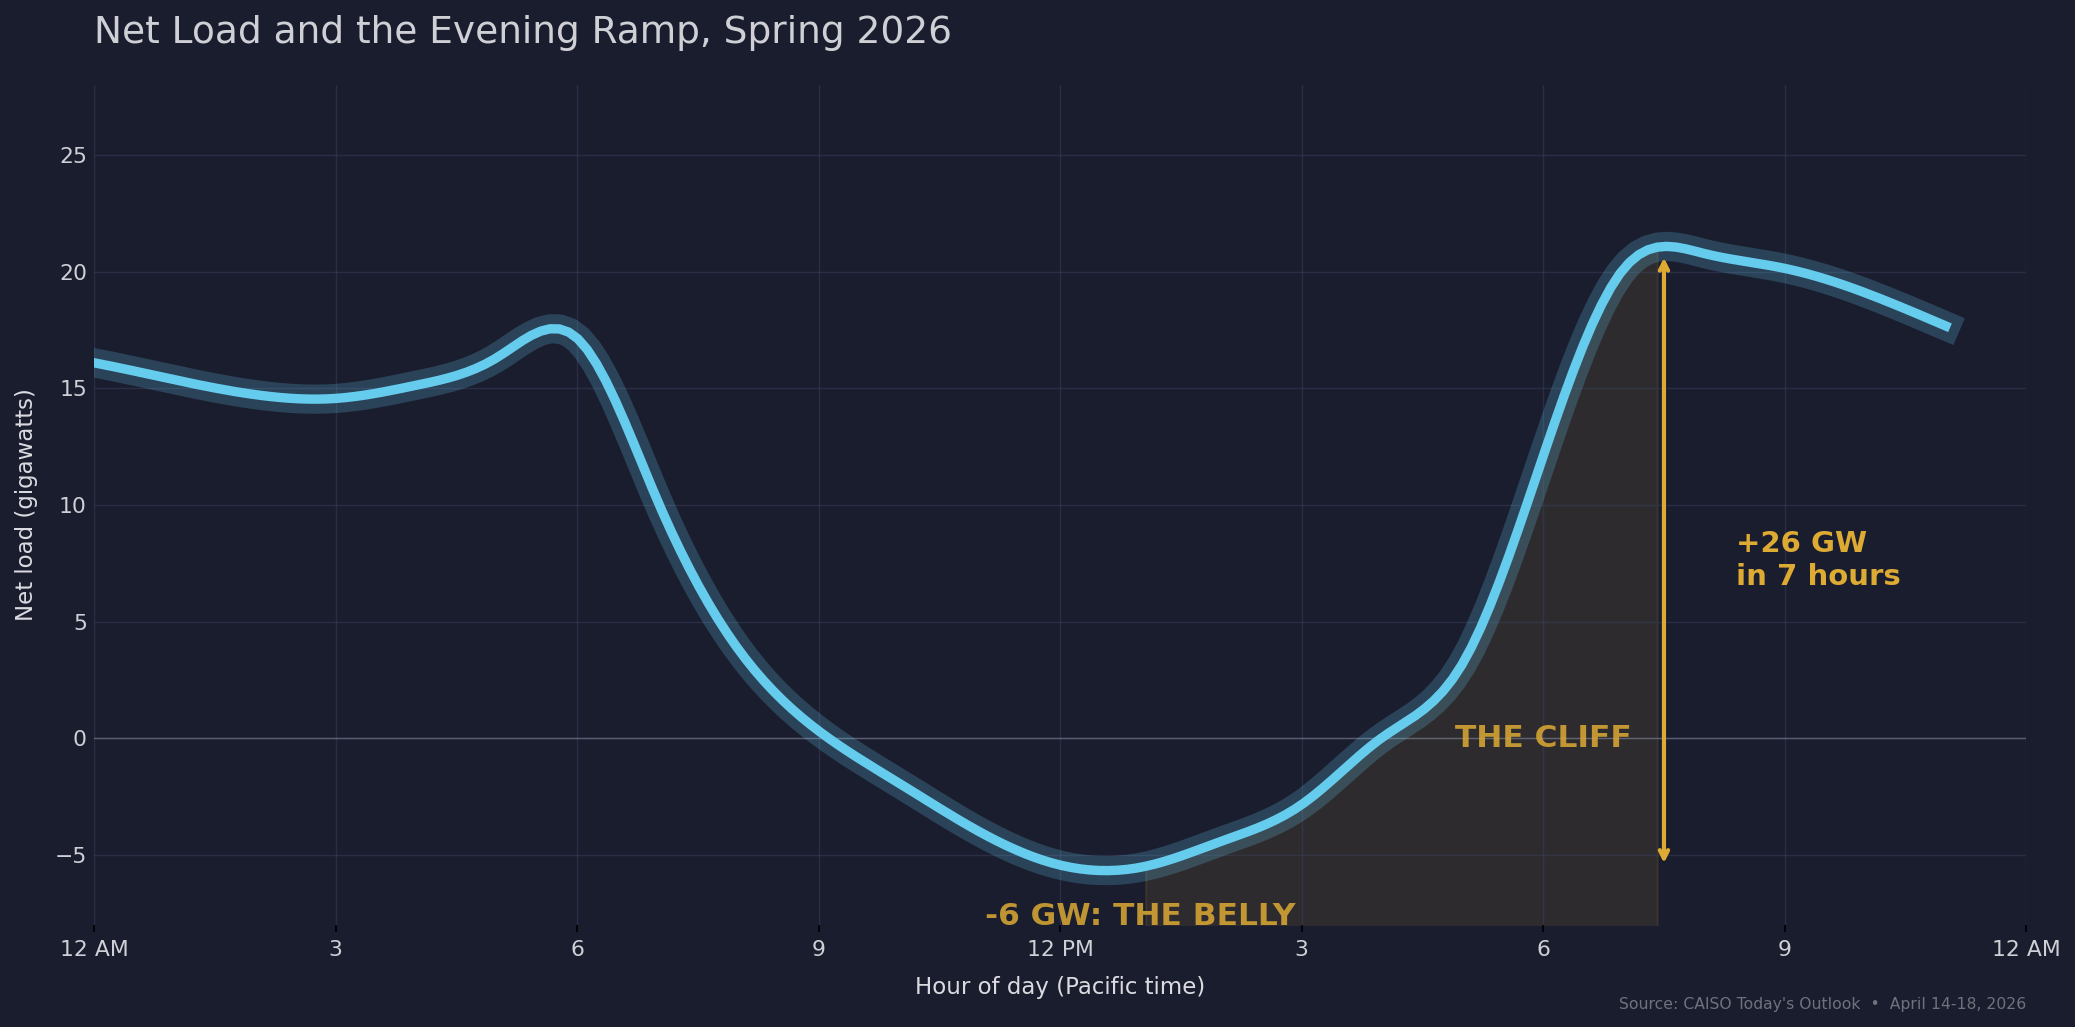

In [37]:
# Figure 2: The cliff
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

BG = '#1a1d2e'
TEXT = '#f0f0f5'
CYAN = '#66CCEE'
AMBER = '#DDAA33'
GRID = '#3a3f5a'

netload_latest = years_data[LATEST_YEAR]['net_load']
hours = np.arange(24)
hours_smooth = np.linspace(0, 23, 200)
def smooth(arr):
    return interp1d(hours, arr, kind='cubic')(hours_smooth)

belly_hour = int(np.argmin(netload_latest))
peak_hour = int(np.argmax(netload_latest[16:22])) + 16
ramp_size = netload_latest[peak_hour] - netload_latest[belly_hour]
ramp_hours = peak_hour - belly_hour

fig = plt.figure(figsize=(14, 7), dpi=150)
fig.patch.set_facecolor(BG)
ax = fig.add_axes([0.065, 0.10, 0.92, 0.80])
ax.set_facecolor(BG)
ax.grid(color=GRID, alpha=0.5, linewidth=0.7, zorder=0)
ax.axhline(0, color=TEXT, alpha=0.25, linewidth=0.7)

ramp_mask = (hours_smooth >= belly_hour) & (hours_smooth <= peak_hour-0.5)
ax.fill_between(hours_smooth, smooth(netload_latest), -10,
                where=ramp_mask, color=AMBER, alpha=0.10, zorder=1)
ax.plot(hours_smooth, smooth(netload_latest), color=CYAN, linewidth=14, alpha=0.22, zorder=2)
ax.plot(hours_smooth, smooth(netload_latest), color=CYAN, linewidth=4.5, alpha=1.0, zorder=3)

ax.annotate('', xy=(peak_hour-0.5, netload_latest[peak_hour]),
            xytext=(peak_hour-0.5, netload_latest[belly_hour]),
            arrowprops=dict(arrowstyle='<->', color=AMBER, lw=2))
ax.text(peak_hour + 0.4, (netload_latest[belly_hour] + netload_latest[peak_hour])/2,
        f'+{ramp_size:.0f} GW\nin {ramp_hours} hours',
        color=AMBER, fontsize=14, fontweight='bold', va='center')
ax.text(18, 0, 'THE CLIFF', color=AMBER, fontsize=15, fontweight='bold',
        ha='center', va='center', alpha=0.85)
ax.text(belly_hour, netload_latest[belly_hour] - 1.5, '-6 GW: THE BELLY',
        color=AMBER, fontsize=15, fontweight='bold',
        ha='center', va='top', alpha=0.85)

ax.set_xlabel('Hour of day (Pacific time)', fontsize=11, color=TEXT, alpha=0.9, labelpad=8)
ax.set_ylabel('Net load (gigawatts)', fontsize=11, color=TEXT, alpha=0.9, labelpad=8)
ax.set_xlim(0, 24)
ax.set_ylim(-8, 28)
ax.set_xticks(np.arange(0, 25, 3))
ax.set_xticklabels(['12 AM', '3', '6', '9', '12 PM', '3', '6', '9', '12 AM'],
                    fontsize=10.5, color=TEXT, alpha=0.85)
ax.set_yticks(np.arange(-5, 29, 5))
ax.tick_params(axis='y', colors=TEXT, length=0, labelsize=10.5)
for label in ax.get_yticklabels():
    label.set_alpha(0.85)
for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(0.065, 0.94, f"Net Load and the Evening Ramp, Spring {LATEST_YEAR}",
         fontsize=18, color=TEXT, alpha=0.85)
fig.text(0.985, 0.02, f"Source: CAISO Today's Outlook  \u2022  April 14-18, {LATEST_YEAR}",
         fontsize=7.5, color=TEXT, alpha=0.4, ha='right')

plt.savefig('/content/fig2_cliff.png', facecolor=BG, dpi=150, bbox_inches='tight')
plt.show()

## Figure 3: The duck has been getting fatter

We have data for every April from 2018 through 2026. Figure 3 plots all 9 years on the same axes, with 2018 in pink at the top and 2026 in blue at the bottom. Each year you can see the belly drop a little further. In 2018, midday net load was around 9 GW. By 2026 it's around -6 GW — meaning solar now produces well more than the grid needs at midday, and the surplus has to go somewhere (storage, exports, or curtailment).

The evening peak hasn't moved much — it's stayed around 20-22 GW the whole time. So as the belly drops while the peak stays put, the cliff gets steeper. The same gas fleet has to do more cycling, faster, every year.

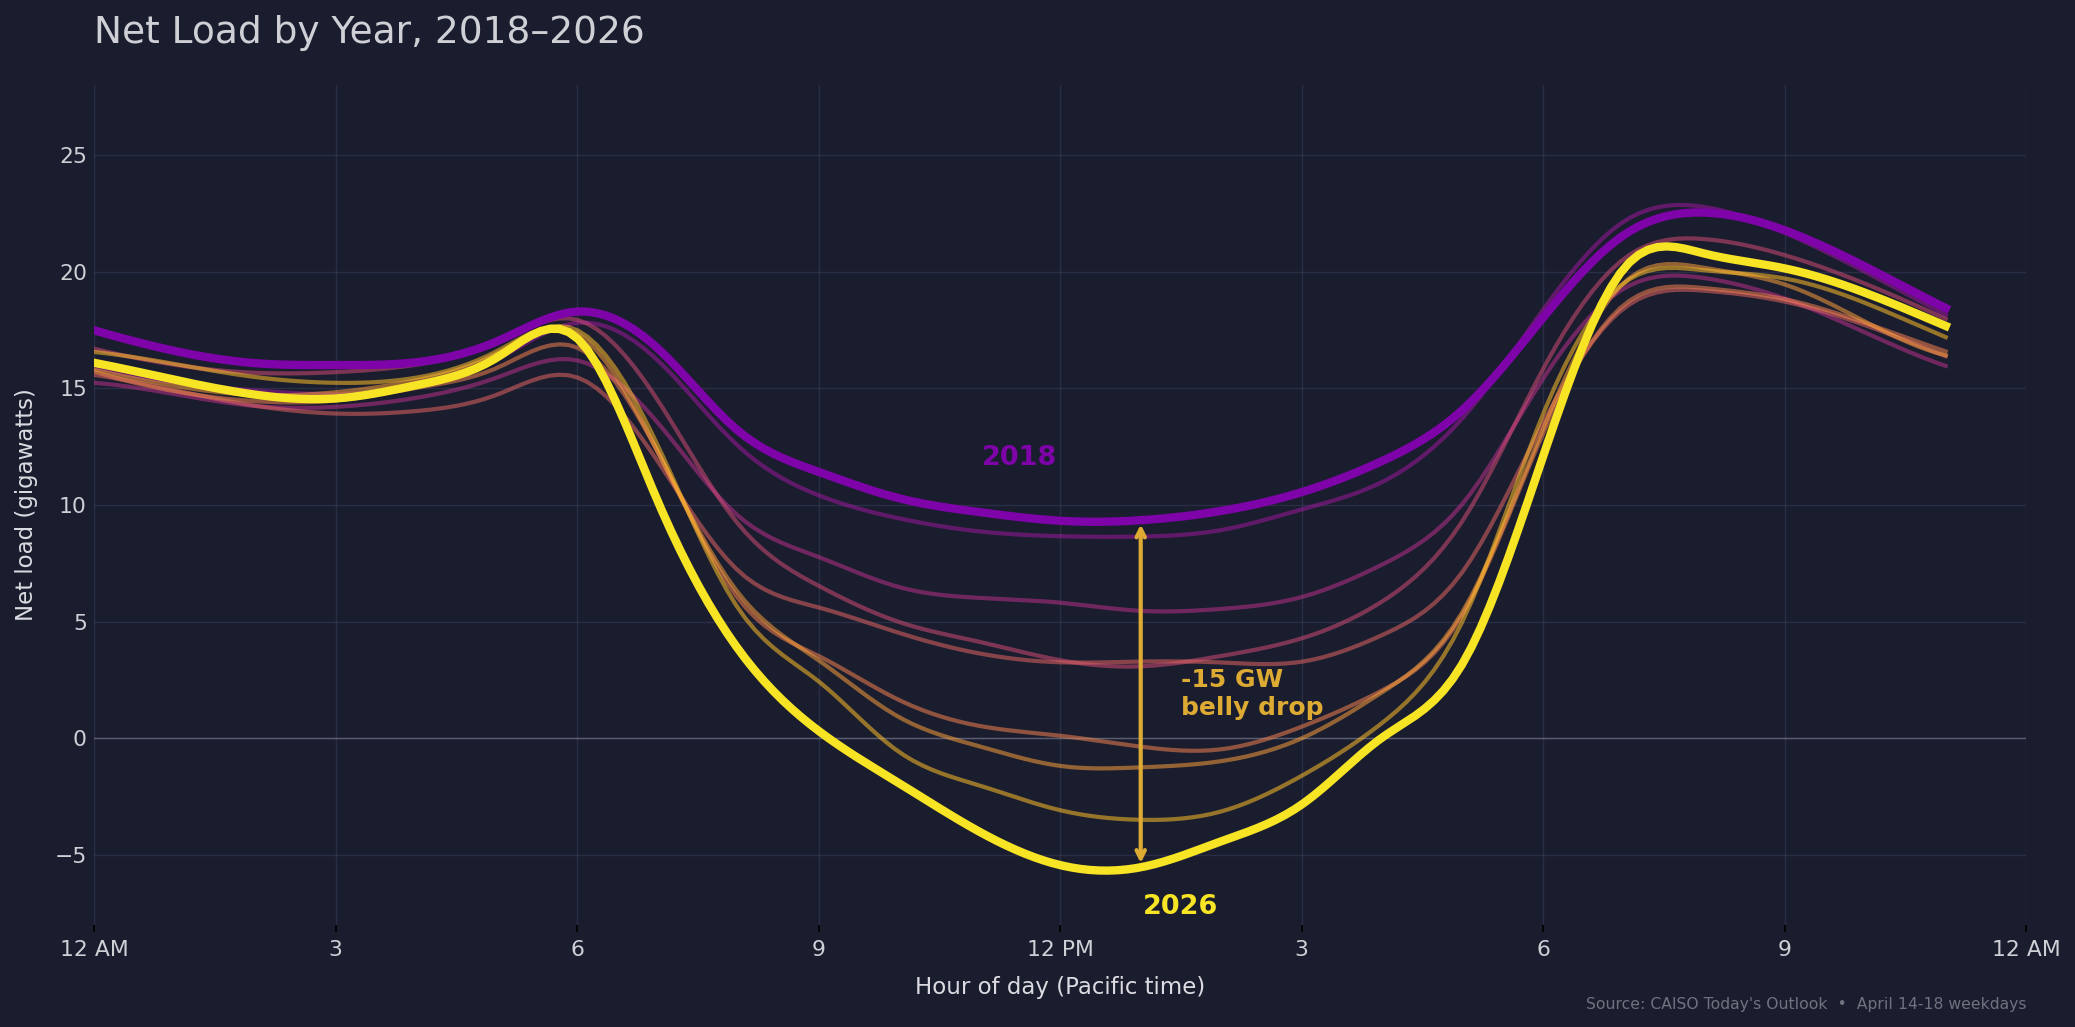

In [32]:
# Figure 3: The duck has been getting fatter (year-over-year progression)
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

BG = '#1a1d2e'
TEXT = '#f0f0f5'
AMBER = '#DDAA33'
GRID = '#3a3f5a'

hours = np.arange(24)
hours_smooth = np.linspace(0, 23, 200)
def smooth(arr):
    return interp1d(hours, arr, kind='cubic')(hours_smooth)

years_sorted = sorted(years_data.keys())
year_colors = plt.cm.plasma(np.linspace(0.25, 0.95, len(years_sorted)))

fig = plt.figure(figsize=(14, 7), dpi=150)
fig.patch.set_facecolor(BG)
ax = fig.add_axes([0.065, 0.10, 0.92, 0.80])
ax.set_facecolor(BG)
ax.grid(color=GRID, alpha=0.5, linewidth=0.7, zorder=0)
ax.axhline(0, color=TEXT, alpha=0.25, linewidth=0.7)

for i, year in enumerate(years_sorted):
    nl = years_data[year]['net_load']
    is_highlight = year in (FIRST_YEAR, LATEST_YEAR)
    lw = 4.0 if is_highlight else 2.0
    alpha = 1.0 if is_highlight else 0.55
    color = year_colors[i]
    ax.plot(hours_smooth, smooth(nl), color=color, linewidth=lw, alpha=alpha,
            zorder=4 if is_highlight else 2)

ax.text(11.5, years_data[FIRST_YEAR]['net_load'][11] + 2, str(FIRST_YEAR),
        color=year_colors[0], fontsize=13, fontweight='bold', ha='center')
ax.text(13.5, years_data[LATEST_YEAR]['net_load'][13] - 2, str(LATEST_YEAR),
        color=year_colors[-1], fontsize=13, fontweight='bold', ha='center')

belly_hr = 13
y_first = years_data[FIRST_YEAR]['net_load'][belly_hr]
y_last = years_data[LATEST_YEAR]['net_load'][belly_hr]
belly_drop = y_first - y_last
ax.annotate('', xy=(belly_hr, y_last), xytext=(belly_hr, y_first),
            arrowprops=dict(arrowstyle='<->', color=AMBER, lw=2))
ax.text(belly_hr + 0.5, (y_first + y_last) / 2,
        f'-{belly_drop:.0f} GW\nbelly drop',
        color=AMBER, fontsize=12, fontweight='bold', va='center')

ax.set_xlabel('Hour of day (Pacific time)', fontsize=11, color=TEXT, alpha=0.9, labelpad=8)
ax.set_ylabel('Net load (gigawatts)', fontsize=11, color=TEXT, alpha=0.9, labelpad=8)
ax.set_xlim(0, 24)
ax.set_ylim(-8, 28)
ax.set_xticks(np.arange(0, 25, 3))
ax.set_xticklabels(['12 AM', '3', '6', '9', '12 PM', '3', '6', '9', '12 AM'],
                    fontsize=10.5, color=TEXT, alpha=0.85)
ax.set_yticks(np.arange(-5, 29, 5))
ax.tick_params(axis='y', colors=TEXT, length=0, labelsize=10.5)
for label in ax.get_yticklabels():
    label.set_alpha(0.85)
for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(0.065, 0.94, f"Net Load by Year, {FIRST_YEAR}\u2013{LATEST_YEAR}",
         fontsize=18, color=TEXT, alpha=0.85)
fig.text(0.985, 0.02, "Source: CAISO Today's Outlook  \u2022  April 14-18 weekdays",
         fontsize=7.5, color=TEXT, alpha=0.4, ha='right')

plt.savefig('/content/fig3_progression.png', facecolor=BG, dpi=150, bbox_inches='tight')
plt.show()

## Figure 4: Batteries shift solar to evening

Figures 1 through 3 set up the problem: net load drops deep at midday and shoots back up at sunset, creating a steep evening ramp that gets worse every year. This figure shows what batteries are doing about it.

The solid coral line is the 2026 duck — same one from Figure 1. The dashed gray line is what's left over for gas, nuclear, and other dispatchable resources to supply, once you account for what batteries are doing. The shaded regions show battery activity:

- **Cyan above the duck (midday)**: batteries are charging. They draw power from the grid and store it, effectively raising the load the grid sees during midday solar surplus hours. This is solar electricity that would otherwise be curtailed, now being stored instead.
- **Orange below the duck (evening)**: batteries are discharging. They supply power back to the grid during the evening peak, reducing how much the gas fleet has to ramp up. The dashed line peaks several gigawatts lower than the duck does.

Batteries don't erase the cliff. They shrink it back to roughly what the grid used to handle before solar reshaped the day, which means the gas fleet can ramp at the kind of pace it was originally built for.

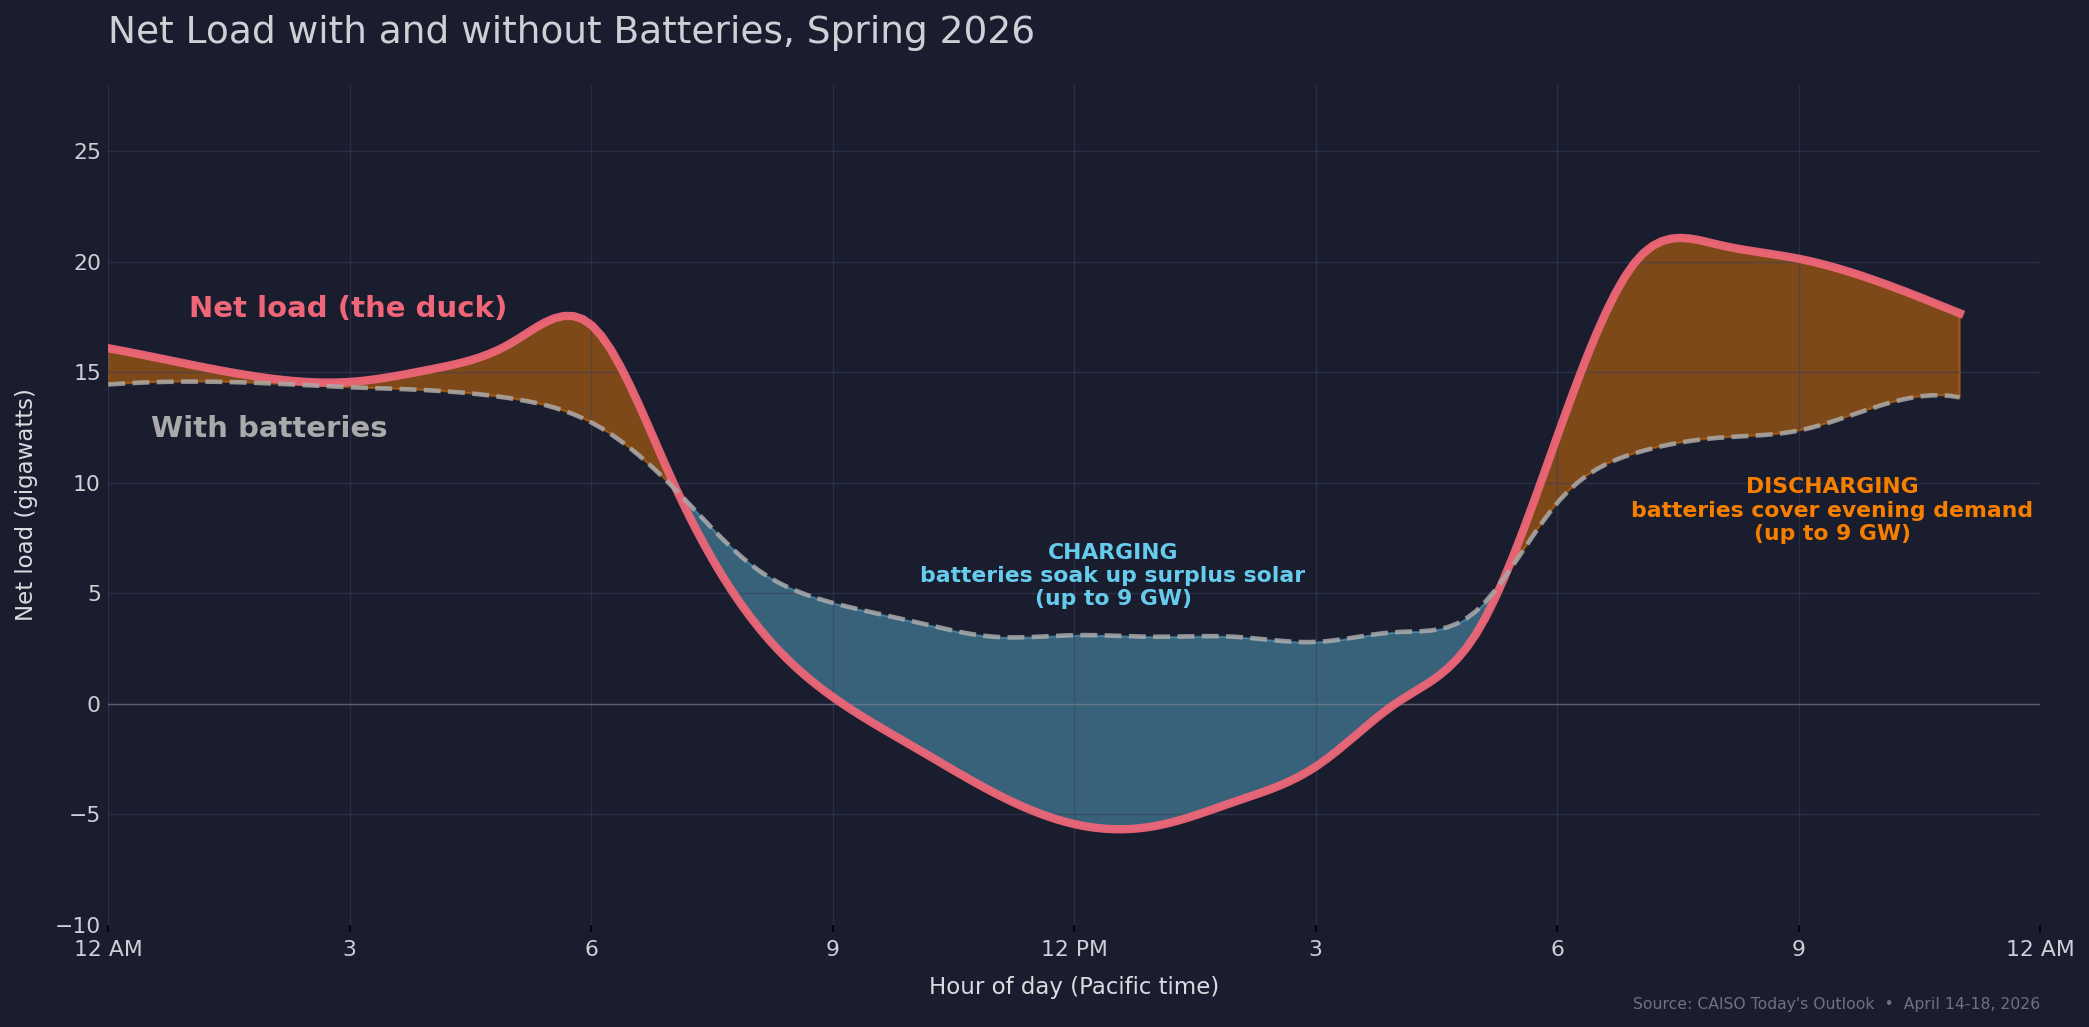

In [35]:
# Figure 4: Batteries shift solar to evening
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

BG = '#1a1d2e'
TEXT = '#f0f0f5'
CYAN = '#66CCEE'
CORAL = '#EE6677'
ORANGE = '#F77F00'
GRID = '#3a3f5a'
GRAY = '#AAAAAA'

netload = years_data[LATEST_YEAR]['net_load']
batteries = years_data[LATEST_YEAR]['batteries']
with_bat = netload - batteries

hours = np.arange(24)
hours_smooth = np.linspace(0, 23, 200)
def smooth(arr):
    return interp1d(hours, arr, kind='cubic')(hours_smooth)

duck_smooth = smooth(netload)
with_bat_smooth = smooth(with_bat)
bat_smooth = smooth(batteries)

fig = plt.figure(figsize=(14, 7), dpi=150)
fig.patch.set_facecolor(BG)
ax = fig.add_axes([0.065, 0.10, 0.92, 0.80])
ax.set_facecolor(BG)
ax.grid(color=GRID, alpha=0.5, linewidth=0.7, zorder=0)
ax.axhline(0, color=TEXT, alpha=0.25, linewidth=0.7)

discharge_mask = bat_smooth >= 0
ax.fill_between(hours_smooth, with_bat_smooth, duck_smooth,
                where=discharge_mask, color=ORANGE, alpha=0.45, zorder=1, interpolate=True)

charge_mask = bat_smooth < 0
ax.fill_between(hours_smooth, duck_smooth, with_bat_smooth,
                where=charge_mask, color=CYAN, alpha=0.40, zorder=1, interpolate=True)

ax.plot(hours_smooth, duck_smooth, color=CORAL, linewidth=4.0, alpha=0.95, zorder=3)
ax.plot(hours_smooth, with_bat_smooth, color=GRAY, linewidth=2.2, alpha=0.85,
        zorder=3, linestyle='--')

# Inline labels — coral for duck, gray for with-batteries
ax.text(1, duck_smooth[15] + 3.0, 'Net load (the duck)',
        color=CORAL, fontsize=14, fontweight='bold', va='center', ha='left')
ax.text(2, with_bat_smooth[190] - 1, 'With batteries',
        color=GRAY, fontsize=14, fontweight='bold', va='center', ha='center')

# Cyan/orange annotations
midday_idx = int(np.argmin(bat_smooth))
ax.text(hours_smooth[midday_idx], with_bat_smooth[midday_idx] + 1.2,
        f'CHARGING\nbatteries soak up surplus solar\n(up to {abs(batteries.min()):.0f} GW)',
        color=CYAN, fontsize=10.5, fontweight='bold', va='bottom', ha='center')

evening_idx = int(np.argmax(bat_smooth))
ax.text(hours_smooth[evening_idx]+2, with_bat_smooth[evening_idx] - 1.5,
        f'DISCHARGING\nbatteries cover evening demand\n(up to {batteries.max():.0f} GW)',
        color=ORANGE, fontsize=10.5, fontweight='bold', va='top', ha='center')

ax.set_xlabel('Hour of day (Pacific time)', fontsize=11, color=TEXT, alpha=0.9, labelpad=8)
ax.set_ylabel('Net load (gigawatts)', fontsize=11, color=TEXT, alpha=0.9, labelpad=8)
ax.set_xlim(0, 24)
ax.set_ylim(-10, 28)
ax.set_xticks(np.arange(0, 25, 3))
ax.set_xticklabels(['12 AM', '3', '6', '9', '12 PM', '3', '6', '9', '12 AM'],
                    fontsize=10.5, color=TEXT, alpha=0.85)
ax.set_yticks(np.arange(-10, 29, 5))
ax.tick_params(axis='y', colors=TEXT, length=0, labelsize=10.5)
for label in ax.get_yticklabels():
    label.set_alpha(0.85)
for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(0.065, 0.94, f"Net Load with and without Batteries, Spring {LATEST_YEAR}",
         fontsize=18, color=TEXT, alpha=0.85)
fig.text(0.985, 0.02, f"Source: CAISO Today's Outlook  \u2022  April 14-18, {LATEST_YEAR}",
         fontsize=7.5, color=TEXT, alpha=0.4, ha='right')

plt.savefig('/content/fig4_batteries.png', facecolor=BG, dpi=150, bbox_inches='tight')
plt.show()

# Interpretations and conclusions

The data supports three main observations.

1. **The midday belly has deepened steadily for nine consecutive years.** In 2018, California's midday net load was around 9 GW on a spring weekday. By 2026 it was around -6 GW, meaning solar was producing well more than the grid needed for several hours every afternoon. That's a 15 GW drop in 9 years, driven almost entirely by utility-scale and rooftop solar growth.

2. **The evening peak hasn't changed much.** Across all 9 years, the 8 PM peak has stayed around 20-22 GW. So as the belly has dropped while the peak has held steady, the evening ramp has gotten progressively steeper. In 2018, gas plants ramped roughly 13 GW from belly to peak. By 2026, the ramp is closer to 26 GW.

3. **Battery storage is taking on a meaningful share of the evening ramp.** From essentially zero in 2018, CAISO's grid-scale batteries discharged up to nearly 9 GW during the evening cliff in spring 2026, on an average weekday. They also charged nearly 9 GW at midday, absorbing solar that would otherwise have been curtailed. Net effect: a significant chunk of the ramp that would otherwise fall on gas plants is now handled by stored solar from earlier the same day.

The duck curve isn't a sign that the grid is failing; it's a shift in what the grid has to manage. Before solar, operators planned around a single predictable evening peak. With solar covering most of the midday demand, the operational challenge has moved from meeting a peak to managing the transition into and out of midday — particularly the evening ramp, which has gotten steeper as the belly has deepened. Grid-scale storage is the most consequential response to that shift currently being deployed at scale.

# Future directions

Several extensions of this analysis would be worth pursuing:

- **Seasonal comparison.** Spring isolates the duck most clearly, but the shape varies dramatically by season. A summer week would show a much higher evening peak (driven by air conditioning) and a less dramatic relative belly. A winter week would show the lowest solar contribution and the highest baseline demand.
- **Comparison with other regions.** Texas (ERCOT), Hawaii, and parts of Australia are seeing similar duck-curve dynamics emerge in their own grids. A cross-ISO comparison would show whether California is uniquely far along this trajectory or whether other regions are catching up.
- **Curtailment estimation.** The data here doesn't directly show how much solar is being curtailed (turned away because the grid can't accept it). Combining CAISO curtailment reports with the net load data would let us estimate how much of the midday solar surplus is being wasted vs stored.
- **Battery duration impacts.** Current CAISO batteries are mostly 4-hour systems. Longer-duration storage (8+ hours) is starting to enter the market and would change the shape of the with-batteries curve significantly. A forward-looking analysis using NREL deployment scenarios could project what the duck might look like by 2030.
- **Cost analysis.** The cliff isn't just an engineering problem, it's an economic one. Evening wholesale prices in CAISO frequently spike during the ramp. Pairing the load shape data with hourly LMP data would quantify the dollar cost of the duck.

# Acknowledgements

**Data source.** CAISO Today's Outlook dashboard (https://www.caiso.com/todays-outlook). The duck curve concept was first named in CAISO's 2013 report "Fast Facts: What the Duck Curve Tells Us About Managing a Green Grid."

**Image credit.** Opening photograph of high-voltage substation infrastructure courtesy of PondCo, "Designing Electrical Substations for a Modernized Energy Grid" (https://www.pondco.com/blog/designing-electrical-substations-for-a-modernized-energy-grid).

**AI assistance.** This project was developed with the help of two AI tools. Anthropic's Claude was used for iterative discussion of the narrative framing, data visualization design, figure refinement, and writing assistance. Google's Gemini (built into Colab) was used for code generation and notebook editing. All analytical decisions, final narrative choices, and interpretations of the data are my own.

**Thanks.** To Professor Jeremy Manning and PSYC 81.09 (Storytelling with Data) at Dartmouth College.